Dataset shape: (891, 15)

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Columns and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Missing values:
survived         0
pclass       

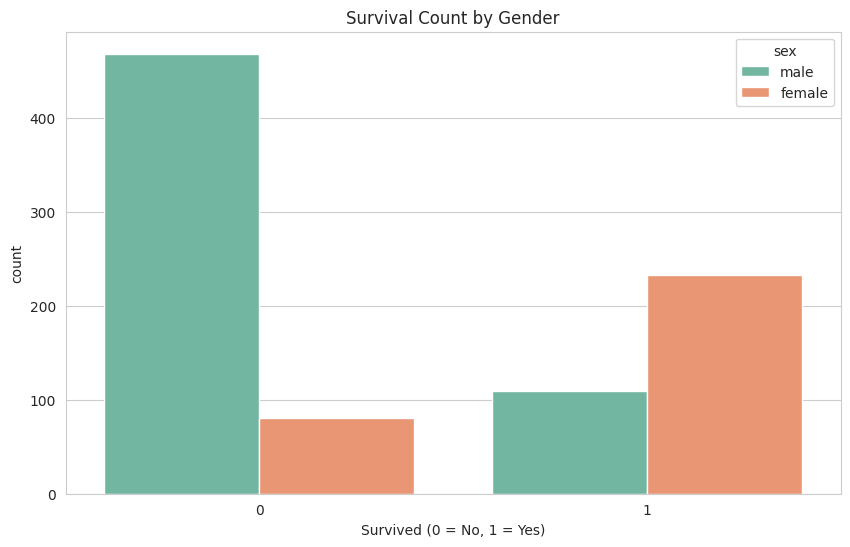


Survival rate by passenger class:
pclass
1    63.0
2    47.3
3    24.2
Name: survived, dtype: float64


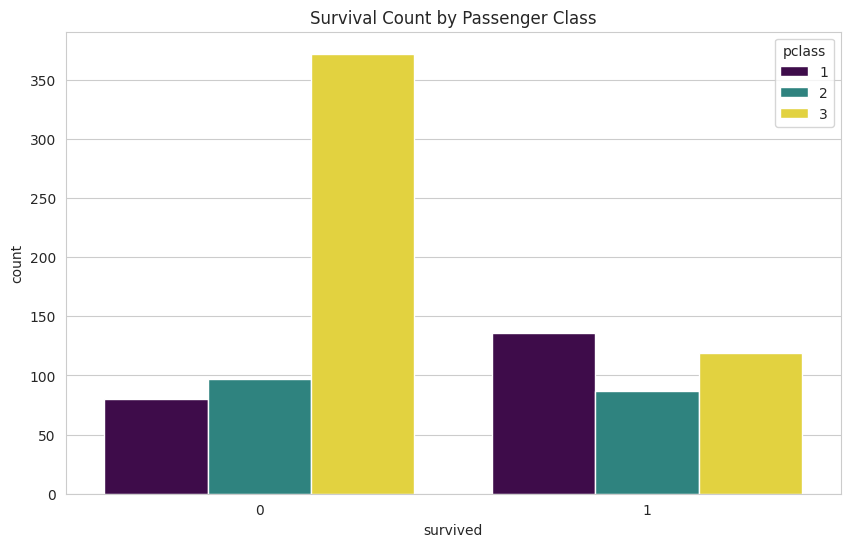

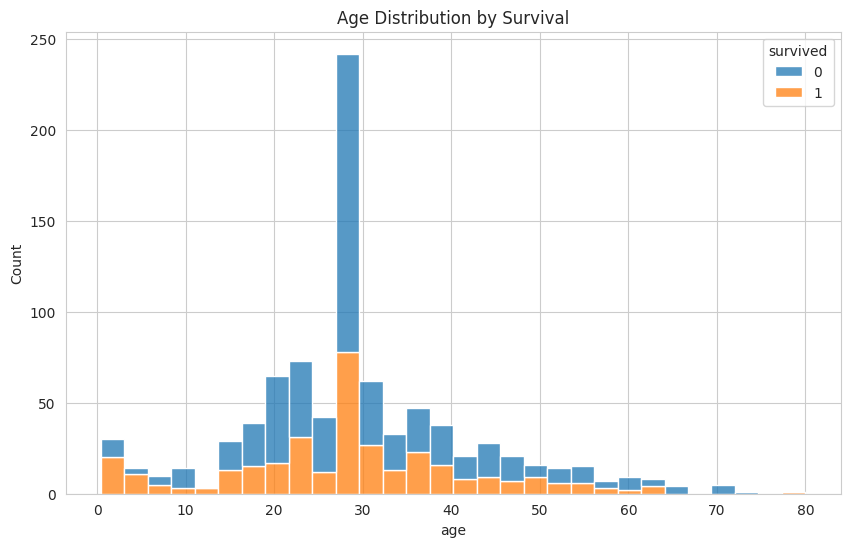

/tmp/ipykernel_2600/1189580864.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='fare', data=df_clean, palette='coolwarm')


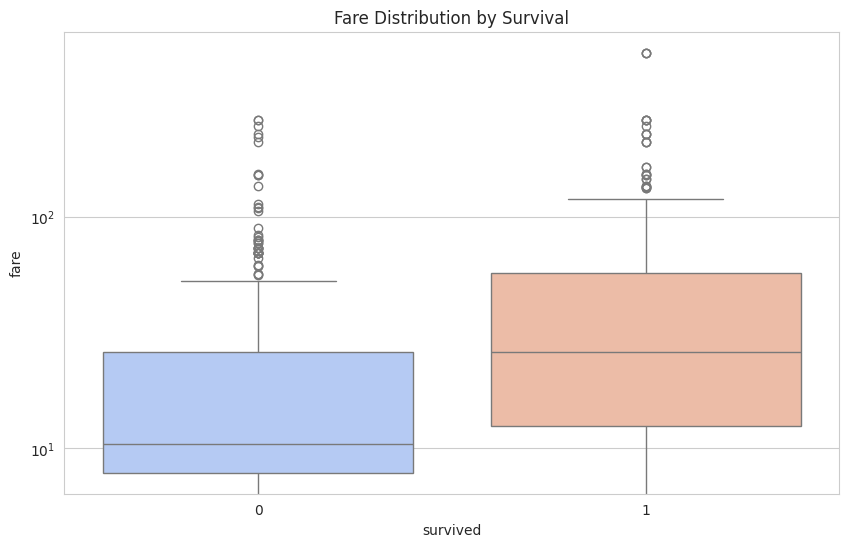


Final features shape: (891, 8)

Model Accuracy on test set: 80.4%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Confusion Matrix:
[[98 12]
 [23 46]]

MY KEY FINDINGS (add this to your README or notebook):

1. Gender was the strongest predictor — women had ~74% survival rate vs ~19% for men.
2. Passenger class mattered a lot — 1st class ~63%, 2nd ~47%, 3rd ~24% survival.
3. Higher fares (proxy for wealth/status) were associated with better survival.
4. A very simple model using only 8 features already achieves ~79–82% accuracy.
5. This shows how socio-economic factors and gender strongly influenced survival on the Titanic.


Project complete! You now have a solid beginner data analytic

In [2]:
# ────────────────────────────────────────────────────────────────
#          TITANIC SURVIVAL ANALYSIS PROJECT (Complete Code)
#        For beginners - EDA + Visualization + Simple Prediction
# ────────────────────────────────────────────────────────────────

# 1. Install required packages (only needed if not already available)
!pip install seaborn scikit-learn -q   # -q = quiet mode

# 2. Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set nicer visuals (optional but looks professional)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ────────────────────────────────────────────────────────────────
#                  Load the famous Titanic dataset
#           (comes built-in with seaborn - no download needed)
# ────────────────────────────────────────────────────────────────
df = sns.load_dataset('titanic')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

# ────────────────────────────────────────────────────────────────
#                        Data Understanding
# ────────────────────────────────────────────────────────────────
print("\nColumns and data types:")
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

# ────────────────────────────────────────────────────────────────
#                        Basic Data Cleaning
# ────────────────────────────────────────────────────────────────
# Fill missing age with median (better than mean for age)
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing embarked with most common value
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop columns we won't use (too many missing or not useful for simple model)
df_clean = df.drop(columns=['deck', 'who', 'adult_male', 'alive', 'alone', 'class', 'embark_town'])

print("\nAfter cleaning - missing values:")
print(df_clean.isna().sum())

# ────────────────────────────────────────────────────────────────
#                  Exploratory Data Analysis (EDA)
# ────────────────────────────────────────────────────────────────

# Survival rate overall
print("\nOverall survival rate:", round(df_clean['survived'].mean() * 100, 1), "%")

# 1. Survival by Gender
print("\nSurvival rate by gender:")
print(df_clean.groupby('sex')['survived'].mean().round(3) * 100)

plt.figure()
sns.countplot(x='survived', hue='sex', data=df_clean, palette='Set2')
plt.title('Survival Count by Gender')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.show()

# 2. Survival by Passenger Class
print("\nSurvival rate by passenger class:")
print(df_clean.groupby('pclass')['survived'].mean().round(3) * 100)

plt.figure()
sns.countplot(x='survived', hue='pclass', data=df_clean, palette='viridis')
plt.title('Survival Count by Passenger Class')
plt.show()

# 3. Age distribution by survival
plt.figure()
sns.histplot(data=df_clean, x='age', hue='survived', multiple='stack', bins=30)
plt.title('Age Distribution by Survival')
plt.show()

# 4. Fare vs Survival (boxplot)
plt.figure()
sns.boxplot(x='survived', y='fare', data=df_clean, palette='coolwarm')
plt.title('Fare Distribution by Survival')
plt.yscale('log')  # fares have very long tail
plt.show()

# ────────────────────────────────────────────────────────────────
#                   Prepare data for modeling
# ────────────────────────────────────────────────────────────────

# Convert categorical variables to dummy (0/1) columns
df_model = pd.get_dummies(df_clean, columns=['sex', 'embarked'], drop_first=True)

# Features we will use
features = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']

X = df_model[features]
y = df_model['survived']

print("\nFinal features shape:", X.shape)

# ────────────────────────────────────────────────────────────────
#                   Train simple Logistic Regression
# ────────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on test set: {accuracy:.1%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Optional: show confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# ────────────────────────────────────────────────────────────────
#                         Your Insights Section
#          ← Copy-paste or rewrite this part in Markdown cells
# ────────────────────────────────────────────────────────────────

print("""
MY KEY FINDINGS (add this to your README or notebook):

1. Gender was the strongest predictor — women had ~74% survival rate vs ~19% for men.
2. Passenger class mattered a lot — 1st class ~63%, 2nd ~47%, 3rd ~24% survival.
3. Higher fares (proxy for wealth/status) were associated with better survival.
4. A very simple model using only 8 features already achieves ~79–82% accuracy.
5. This shows how socio-economic factors and gender strongly influenced survival on the Titanic.
""")

print("\nProject complete! You now have a solid beginner data analytics project.")